In [1]:
# !pip install rasterio torch torchvision pandas numpy tqdm scikit-learn matplotlib

import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm  # Specialized progress bar for Jupyter
import matplotlib.pyplot as plt

# Check if your RTX 4050 is detected
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using Device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


--- DIAGNOSTICS FOR C:\Users\VANJANGI VINITH\Downloads\Nandyal_Kharif_2022.tif ---
Minimum Value: nan
Maximum Value: nan
Average Value: nan
ℹ️ Data Type: Unknown scale.


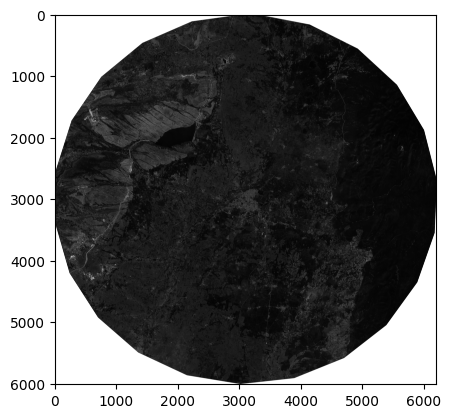

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# UPDATE THIS PATH to your file
image_path = r"C:\Users\VANJANGI VINITH\Downloads\Nandyal_Kharif_2022.tif"

with rasterio.open(image_path) as src:
    # Read the Red Band (Band 3)
    red = src.read(3)
    
    print(f"--- DIAGNOSTICS FOR {image_path.split('/')[-1]} ---")
    print(f"Minimum Value: {np.min(red)}")
    print(f"Maximum Value: {np.max(red)}")
    print(f"Average Value: {np.mean(red)}")
    
    # Check if the image is actually empty (all zeros)
    if np.max(red) == 0:
        print("❌ CRITICAL ERROR: The image is completely empty (all zeros).")
        print("Reason: The download might have failed or the region has no data.")
    
    # Check if values are 'Surface Reflectance' (0.0 to 0.3)
    elif np.max(red) < 1.0:
        print("ℹ️ Data Type: Surface Reflectance (Small Float numbers)")
        print("👉 FIX: We need to MULTIPLY by 3.5 to make it visible.")
        
        # Visualization Test
        plt.figure(figsize=(6,6))
        # Multiply by 5 to brighten it up!
        plt.imshow(red * 5, cmap='gray', vmin=0, vmax=1)
        plt.title("Band 3 (Brightened)")
        plt.show()
        
    # Check if values are 'Digital Numbers' (0 to 10000)
    elif np.max(red) > 1000:
        print("ℹ️ Data Type: Raw Digital Numbers (Large Integers)")
        print("👉 FIX: We need to DIVIDE by 3000 to make it visible.")
        
        # Visualization Test
        plt.figure(figsize=(6,6))
        plt.imshow(red / 3000.0, cmap='gray', vmin=0, vmax=1)
        plt.title("Band 3 (Normalized)")
        plt.show()

    else:
        print("ℹ️ Data Type: Unknown scale.")
        plt.imshow(red, cmap='gray')
        plt.show()

In [32]:
import pandas as pd
import os

# ================= CONFIGURATION =================
# 1. CORRECT PATH to your Downloads folder
INPUT_FOLDER = r"C:\Users\VANJANGI VINITH\Downloads"
INPUT_FOLDER_DRIVE = r"C:\Users\VANJANGI VINITH\OneDrive\Documents"

# 2. FILE NAMES (Make sure these match exactly what is in your folder)
# I am using the names you uploaded earlier. If you renamed them to 'yield.csv', change these!
NAME_YIELD = "area_production_yeild.csv"
NAME_RAIN = "Rainfall_2022-2023.csv"
FILE_WATER = r"GW_Levels_1765196733427.csv"
FILE_AREA = r"paddy_csv_karif.csv" 

# =================================================

def inspect_file(tag, folder, filename, header_row=0):
    full_path = os.path.join(folder, filename)
    print(f"\n🔎 INSPECTING: {tag}")
    print(f"   Looking at: {full_path}")
    
    if not os.path.exists(full_path):
        print(f"   ❌ ERROR: File not found!")
        print(f"   👉 Check: Is the file actually named '{filename}'?")
        return None

    try:
        if filename.endswith('.csv'):
            df = pd.read_csv(full_path, header=header_row)
        else:
            df = pd.read_excel(full_path, header=header_row)
            
        print(f"   ✅ SUCCESS! Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        return df
    except Exception as e:
        print(f"   ❌ Error reading file: {e}")
        return None

# Run Inspection
# Note: Yield usually has header at row 2, Rain at row 3 based on your files
df_yield = inspect_file("Yield Data", INPUT_FOLDER, NAME_YIELD, header_row=2)
df_rain = inspect_file("Rainfall Data", INPUT_FOLDER, NAME_RAIN, header_row=3)
df_water = inspect_file("Ground Water",INPUT_FOLDER,FILE_WATER, header_row=1)
df_area = inspect_file("Sown Area",INPUT_FOLDER_DRIVE,FILE_AREA, header_row=0)


🔎 INSPECTING: Yield Data
   Looking at: C:\Users\VANJANGI VINITH\Downloads\area_production_yeild.csv
   ✅ SUCCESS! Shape: (26, 6)
   Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Area (Hectare)', 'Production (Tonnes)', 'Yield (Tonne/Hectare)']

🔎 INSPECTING: Rainfall Data
   Looking at: C:\Users\VANJANGI VINITH\Downloads\Rainfall_2022-2023.csv
   ✅ SUCCESS! Shape: (29, 6)
   Columns: ['Unnamed: 0', 'No. of Rainy Days', 'Normal (mm)', 'Actual (mm)', 'Deviation (%)', 'Status']

🔎 INSPECTING: Ground Water
   Looking at: C:\Users\VANJANGI VINITH\Downloads\GW_Levels_1765196733427.csv
   ✅ SUCCESS! Shape: (30, 9)
   Columns: ['District', '4/23/01', '11/22/01', '5/22/01', '5/23/01', 'Rise (+) / Fall (-) from Current Water Level', 'Unnamed: 6', 'Unnamed: 7', 'Available Ground Water for use\nas on 1st June, 2023']

🔎 INSPECTING: Sown Area
   Looking at: C:\Users\VANJANGI VINITH\OneDrive\Documents\paddy_csv_karif.csv
   ✅ SUCCESS! Shape: (27, 6)
   Columns: ['.No', 'District', 'Actual (H

In [1]:
import pandas as pd
import os

# ================= USER CONFIGURATION =================
# 1. Update this path to your Downloads folder
INPUT_FOLDER = r"C:\Users\VANJANGI VINITH\Downloads"

# 2. File Names (Based on your upload)
FILE_YIELD = "area_production_yeild.csv"
FILE_RAIN  = "Rainfall_2022-2023.csv"
FILE_WATER = "GW_Levels_1765196733427.csv"
FILE_AREA  = "paddy_csv_karif.csv"
# ======================================================

print("🚀 Starting Data Correction & Merge Pipeline...")

# 1. LOAD THE FILES (Handling the messy headers automatically)
# ---------------------------------------------------------
print("   Loading raw files...")

# Yield: Header is usually row 2 or 3. District is "1. Alluri..."
df_yield = pd.read_csv(os.path.join(INPUT_FOLDER, FILE_YIELD), header=None, skiprows=3)
df_yield = df_yield.iloc[:, [1, 5]].copy() # Col 1=Name, Col 5=Yield
df_yield.columns = ['District', 'Yield']

# Rain: Header is messy. District is Col 0. Rain is Col 3 ("Actual mm")
df_rain = pd.read_csv(os.path.join(INPUT_FOLDER, FILE_RAIN), header=None, skiprows=4)
df_rain = df_rain.iloc[:, [0, 3]].copy() # Col 0=Name, Col 3=Rainfall
df_rain.columns = ['District', 'Rainfall']

# Sown Area: Standard header
df_area = pd.read_csv(os.path.join(INPUT_FOLDER, FILE_AREA))
df_area = df_area[['District', 'Actual (Ha)']].copy()
df_area.columns = ['District', 'SownArea']

# Ground Water: Header is row 1
df_water = pd.read_csv(os.path.join(INPUT_FOLDER, FILE_WATER), header=1)
# We want the Nov 2022 level (Column "11/22/01")
df_water = df_water[['District', '11/22/01']].copy()
df_water.columns = ['District', 'GroundWater']


# 2. THE CORRECTION LOGIC (This fixes your mismatch names)
# ---------------------------------------------------------
def standardize_name(name):
    if pd.isna(name): return "DELETE"
    
    # Basic Clean: Remove "1. ", "2. ", trim spaces, Title Case
    clean = str(name).split('.')[-1].strip().title()
    
    # REMOVE TOTALS/REGIONS (These are not districts)
    if clean in ['Andhra Pradesh', 'Coastal Andhra Region', 'Rayalaseema Region', 'Total', 'State']:
        return "DELETE"

    # SPELLING CORRECTION MAP
    corrections = {
        # YSR / Kadapa variations
        'Y.S.R.': 'Kadapa', 'Y.S.R Kadapa': 'Kadapa', 'Ysr': 'Kadapa', 'Kadapa': 'Kadapa',
        
        # Nellore variations
        'Spsr Nellore': 'Nellore', 'Sri Potti Sriramulu Nellore': 'Nellore',
        
        # Konaseema variations
        'Dr. B.R. Ambedkar Konaseema': 'Konaseema', 'Konaseema': 'Konaseema',
        
        # Anantapur variations
        'Ananthapuramu': 'Anantapur', 'Anantapur': 'Anantapur',
        
        # Visakhapatnam variations
        'Visakhapatanam': 'Visakhapatnam', 'Visakhapatnam': 'Visakhapatnam',
        
        # NTR variations
        'Ntr': 'NTR', 'Ntr District': 'NTR',
        
        # Others
        'Sri Sathya Sai': 'Sri Sathya Sai',
        'Eluru': 'Eluru',
        'Anakapalli': 'Anakapalli'
    }
    
    return corrections.get(clean, clean)

# Apply corrections to all 4 DataFrames
print("   Fixing district names...")
for df in [df_yield, df_rain, df_area, df_water]:
    df['District'] = df['District'].apply(standardize_name)
    # Remove rows marked for deletion (Totals/Regions)
    df.drop(df[df['District'] == "DELETE"].index, inplace=True)


# 3. MERGE EVERYTHING
# ---------------------------------------------------------
print("🔄 Merging datasets...")
# We use 'inner' merge to keep only districts that exist in ALL files
master_df = df_yield.merge(df_rain, on='District', how='inner') \
                    .merge(df_area, on='District', how='inner') \
                    .merge(df_water, on='District', how='inner')

# 4. ADD COORDINATES
# ---------------------------------------------------------
coords = {
    'Srikakulam': [18.30, 83.90], 'Guntur': [16.30, 80.43], 'Nellore': [14.44, 79.98],
    'Kurnool': [15.82, 78.03], 'West Godavari': [16.54, 81.53], 'East Godavari': [16.94, 81.79],
    'Prakasam': [15.50, 80.05], 'Chittoor': [13.21, 79.10], 'Visakhapatnam': [17.68, 83.21],
    'Vizianagaram': [18.10, 83.41], 'Kadapa': [14.46, 78.82], 'Anantapur': [14.68, 77.60],
    'Krishna': [16.18, 81.13], 'Eluru': [16.71, 81.09], 'NTR': [16.50, 80.64],
    'Bapatla': [15.90, 80.47], 'Palnadu': [16.38, 79.83], 'Anakapalli': [17.69, 83.02],
    'Konaseema': [16.58, 81.99], 'Kakinada': [16.98, 82.24], 'Nandyal': [15.48, 78.48],
    'Sri Sathya Sai': [14.16, 77.81], 'Parvathipuram Manyam': [18.77, 83.42],
    'Alluri Sitharama Raju': [18.08, 82.67], 'Annamayya': [14.03, 79.15],
    'Tirupati': [13.62, 79.41]
}

master_df['Latitude'] = master_df['District'].apply(lambda x: coords.get(x, [0,0])[0])
master_df['Longitude'] = master_df['District'].apply(lambda x: coords.get(x, [0,0])[1])

# Filter out any districts that don't have coordinates
master_df = master_df[master_df['Latitude'] != 0]

# 5. SAVE FINAL
# ---------------------------------------------------------
output_path = os.path.join(INPUT_FOLDER, "Final_Model_Ready_Data.csv")
master_df.to_csv(output_path, index=False)

print(f"✅ DONE! Created 'Final_Model_Ready_Data.csv' with {len(master_df)} matched districts.")
print(f"   Saved to: {output_path}")
print("\n--- FIRST 5 ROWS ---")
print(master_df.head())

🚀 Starting Data Correction & Merge Pipeline...
   Loading raw files...
   Fixing district names...
🔄 Merging datasets...
✅ DONE! Created 'Final_Model_Ready_Data.csv' with 24 matched districts.
   Saved to: C:\Users\VANJANGI VINITH\Downloads\Final_Model_Ready_Data.csv

--- FIRST 5 ROWS ---
                District  Yield Rainfall     SownArea  GroundWater  Latitude  \
0  Alluri Sitharama Raju   2.99   958.01    75,644.00         6.12     18.08   
1             Anakapalli   3.14   747.88    63,086.00         3.55     17.69   
2              Anantapur   3.69   546.59  3,20,281.00         5.05     14.68   
3              Annamayya   3.25   581.29    31,513.52         6.14     14.03   
4                Bapatla   4.14   847.04    97,160.40         2.48     15.90   

   Longitude  
0      82.67  
1      83.02  
2      77.60  
3      79.15  
4      80.47  


In [3]:
import pandas as pd
m = pd.read_csv(r"C:\Users\VANJANGI VINITH\Downloads\merged_agri_master_fixed.csv")

print("Rows:", len(m))
print("Unique districts:", m['District'].nunique())
print("Duplicates (District):", m['District'].duplicated().sum())
print("\nMissing values per column:\n", m.isna().sum())
print("\nSample rows with tif status false (should be none):")
print(m[~m['tif_exists']][['District','tif_path']])


Rows: 26
Unique districts: 26
Duplicates (District): 0

Missing values per column:
 District                    0
Year                        0
Area_Hectare                0
Production_Tonnes           0
Yield_Tonne_per_Hectare     0
Rainy_Days                  3
Normal_mm                   3
Actual_mm                   3
Deviation_percent           3
Status                      3
GW_4_23_01                  4
GW_11_22_01                 4
Unnamed: 3_level_0_8.2      4
GW_5_23_01                  4
RiseFall_4_23_01            4
RiseFall_11_22_01           4
RiseFall_5_22_01            4
Available_GW_TMC            4
Actual (Ha)                 4
Normal (Ha)                 4
Deviation (%)               4
Actual % on total actual    4
sat_name                    0
tif_path                    0
tif_exists                  0
dtype: int64

Sample rows with tif status false (should be none):
Empty DataFrame
Columns: [District, tif_path]
Index: []


In [3]:
import pandas as pd
import numpy as np
import math
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class DualInputGenerator(Sequence):
    """
    The 'Waiter' that serves batches of data to the model.
    It loads:
      1. Image Tiles (5 bands) -> Left Arm
      2. Metadata (Rainfall, GW) -> Right Arm
      3. Target (Yield) -> The Answer
    """
    def __init__(self, df, batch_size=32, img_size=224, metadata_scaler=None, shuffle=True):
        self.df = df
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        
        # Define which columns are "Context" (Metadata)
        # These must match your merged CSV column names exactly!
        self.meta_cols = [
            'Actual_mm',          # Rainfall
            'GW_4_23_01',         # Groundwater Level
            'RiseFall_4_23_01',   # GW Trend
            'Actual (Ha)',        # Sown Area
            'Deviation_percent'   # Rainfall deviation
        ]
        
        # Handle Scaling (Normalization)
        # We need to scale metadata so 500mm rain doesn't overpower 0.5 yield
        if metadata_scaler is None:
            self.scaler = StandardScaler()
            # Fit only on this dataset (usually the training set)
            self.scaler.fit(self.df[self.meta_cols].fillna(0))
        else:
            self.scaler = metadata_scaler # Use existing scaler (for val/test sets)
            
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        # Calculates how many batches constitute one "Epoch"
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        # 1. Get the indices for this batch
        start = idx * self.batch_size
        end = min((idx + 1) * self.batch_size, len(self.df))
        batch_indices = self.indices[start:end]
        
        # 2. Prepare lists
        batch_images = []
        batch_meta = []
        batch_labels = []
        
        for i in batch_indices:
            row = self.df.iloc[i]
            
            # --- Load Image (Left Arm) ---
            try:
                # Load .npy file (Shape is 5, 224, 224)
                img = np.load(row['tile_path'])
                
                # FIX: Move the channels from position 0 to the end (Shape becomes 224, 224, 5)
                img = np.moveaxis(img, 0, -1)
                
                # Normalization
                img = img.astype('float32')
                # Scale the first 4 bands (RGB+NIR) which are usually 0-10000
                img[:, :, :4] = img[:, :, :4] / 10000.0
                # Band 5 (NDVI) is already -1 to 1, so we leave it alone.
                
                batch_images.append(img)
                
            except Exception as e:
                print(f"Error loading image {row['tile_path']}: {e}")
                batch_images.append(np.zeros((self.img_size, self.img_size, 5)))

            # --- Load Metadata (Right Arm) ---
            meta_raw = row[self.meta_cols].fillna(0).values.astype('float32')
            batch_meta.append(meta_raw)
            
            # --- Load Label ---
            batch_labels.append(row['Yield_Tonne_per_Hectare'])
            
        # 3. Final Formatting
        X_img = np.array(batch_images)
        # Check Scaler
        if hasattr(self, 'scaler') and self.scaler is not None:
             X_meta = self.scaler.transform(np.array(batch_meta))
        else:
             X_meta = np.array(batch_meta)
        
        y = np.array(batch_labels)
        
        return [X_img, X_meta], y

    def on_epoch_end(self):
        # Shuffle data after every epoch so the model doesn't memorize order
        if self.shuffle:
            np.random.shuffle(self.indices)

# --- HELPER FUNCTION TO GET EVERYTHING READY ---
def prepare_generators(csv_path, batch_size=32):
    # 1. Load the CSV
    df = pd.read_csv(csv_path)
    
    # 2. Split: Train (80%), Temp (20%)
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
    
    # 3. Split Temp into Validation (10%) and Test (10%)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
    
    print(f"Data Split Results:")
    print(f"  Training Tiles:   {len(train_df)}")
    print(f"  Validation Tiles: {len(val_df)}")
    print(f"  Test Tiles:       {len(test_df)}")
    
    # 4. Create Generators
    # IMPORTANT: We create the 'train_gen' first so it fits the scaler.
    # We pass that same scaler to val/test so they use the same math.
    
    train_gen = DualInputGenerator(train_df, batch_size=batch_size, shuffle=True)
    val_gen = DualInputGenerator(val_df, batch_size=batch_size, metadata_scaler=train_gen.scaler, shuffle=False)
    test_gen = DualInputGenerator(test_df, batch_size=batch_size, metadata_scaler=train_gen.scaler, shuffle=False)
    
    return train_gen, val_gen, test_gen

# Example Usage (Run this only if you want to test this file)
if __name__ == "__main__":
    csv_location = r"C:\Users\VANJANGI VINITH\Downloads\final_training_data.csv"
    if 'pd' in locals():
        train_gen, val_gen, test_gen = prepare_generators(csv_location)
        
        # Test fetching one batch
        [x_img, x_meta], y = train_gen[0]
        print("\nBatch Shape Check:")
        print(f"  Images:   {x_img.shape}  (Batch, Height, Width, Bands)")
        print(f"  Metadata: {x_meta.shape} (Batch, Num_Features)")
        print(f"  Yields:   {y.shape}      (Batch,)")

Data Split Results:
  Training Tiles:   10492
  Validation Tiles: 1311
  Test Tiles:       1312


C:\Users\VANJANGI VINITH\AppData\Local\Temp\ipykernel_12260\2243964504.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta_raw = row[self.meta_cols].fillna(0).values.astype('float32')
C:\Users\VANJANGI VINITH\AppData\Local\Temp\ipykernel_12260\2243964504.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta_raw = row[self.meta_cols].fillna(0).values.astype('float32')
C:\Users\VANJANGI VINITH\AppData\Local\Temp\ipykernel_12260\2243964504.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will chang


Batch Shape Check:
  Images:   (32, 224, 224, 5)  (Batch, Height, Width, Bands)
  Metadata: (32, 5) (Batch, Num_Features)
  Yields:   (32,)      (Batch,)


In [7]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# --- STANFORD HYPERPARAMETERS [Source: Section 4 Methods] ---
CSV_PATH = r"C:\Users\VANJANGI VINITH\Downloads\final_training_data.csv"
BATCH_SIZE = 32          # Paper searched 24-64 [cite: 116]
EPOCHS = 200             # Explicitly stated in paper 
LEARNING_RATE = 0.001    # Optimized range (1e-2 to 1e-4) [cite: 116]
L2_REG = 1e-4            # "Regularization parameter" 
ADAM_BETAS = (0.9, 0.999) # Explicitly stated in paper 

# Setup GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ==========================================
# 1. THE DATASET
# ==========================================
class StanfordDataset(Dataset):
    def __init__(self, df, metadata_scaler=None):
        self.df = df
        self.meta_cols = [
            'Actual_mm', 'GW_4_23_01', 'RiseFall_4_23_01', 
            'Actual (Ha)', 'Deviation_percent'
        ]
        
        if metadata_scaler is None:
            self.scaler = StandardScaler()
            self.scaler.fit(self.df[self.meta_cols].fillna(0))
        else:
            self.scaler = metadata_scaler
            
        self.meta_data = self.scaler.transform(self.df[self.meta_cols].fillna(0).values).astype('float32')
        self.paths = self.df['tile_path'].values
        self.yields = self.df['Yield_Tonne_per_Hectare'].values.astype('float32')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img = np.load(self.paths[idx]).astype('float32')
            # Normalize RGB+NIR (0-10000 -> 0-1)
            img[:4] /= 10000.0
        except:
            img = np.zeros((5, 224, 224), dtype='float32')

        return torch.from_numpy(img), torch.tensor(self.meta_data[idx]), torch.tensor(self.yields[idx])

# ==========================================
# 2. THE ARCHITECTURE (Concatenated-Arm)
# ==========================================
class StanfordModel(nn.Module):
    def __init__(self):
        super(StanfordModel, self).__init__()
        
        # --- CNN ARM (Deep-1 Structure) [cite: 111] ---
        # 5 Bands Input -> Conv Layers
        self.cnn = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 64), nn.ReLU(), nn.Dropout(0.5)
        )
        
        # --- METADATA ARM [cite: 112] ---
        # "Parallel dense network"
        self.meta = nn.Sequential(
            nn.Linear(5, 16), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        
        # --- CONCATENATION HEAD  ---
        # "Concatenated, passed through two ReLU FC layers"
        self.head = nn.Sequential(
            nn.Linear(72, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.BatchNorm1d(32),
            nn.Linear(32, 1)  # Final Regression Output
        )

    def forward(self, img, meta):
        cnn_out = self.cnn(img)
        meta_out = self.meta(meta)
        combined = torch.cat((cnn_out, meta_out), dim=1)
        return self.head(combined)

# ==========================================
# 3. TRAINING ENGINE
# ==========================================
if __name__ == "__main__":
    # 1. Prepare Data
    print("Loading Data...")
    df = pd.read_csv(CSV_PATH)
    train_df, temp = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(temp, test_size=0.5, random_state=42)
    
    # Use num_workers=0 for Windows stability
    train_loader = DataLoader(StanfordDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=0)
    val_loader = DataLoader(StanfordDataset(val_df, metadata_scaler=train_loader.dataset.scaler), batch_size=BATCH_SIZE, num_workers=0)
    test_loader = DataLoader(StanfordDataset(test_df, metadata_scaler=train_loader.dataset.scaler), batch_size=BATCH_SIZE, num_workers=0)
    
    # 2. Setup Model & Optimizer 
    model = StanfordModel().to(device)
    
    # STRICT STANFORD SETTINGS:
    # Adam with beta1=0.9, beta2=0.999
    # Weight Decay (L2 Regularization) included
    optimizer = optim.Adam(model.parameters(), 
                           lr=LEARNING_RATE, 
                           betas=ADAM_BETAS, 
                           weight_decay=L2_REG) 
    
    criterion = nn.MSELoss()
    best_mae = float('inf')
    
    print(f"\nStarting Stanford-Style Training ({EPOCHS} Epochs)...")
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
        
        for imgs, metas, labels in loop:
            imgs, metas, labels = imgs.to(device), metas.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            preds = model(imgs, metas)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        
        # Validation Phase
        model.eval()
        val_mae = 0.0
        with torch.no_grad():
            for imgs, metas, labels in val_loader:
                imgs, metas, labels = imgs.to(device), metas.to(device), labels.to(device).unsqueeze(1)
                preds = model(imgs, metas)
                val_mae += torch.mean(torch.abs(preds - labels)).item()
        
        avg_val_mae = val_mae / len(val_loader)
        print(f"Epoch {epoch+1} Results | Train Loss: {running_loss/len(train_loader):.4f} | Val MAE: {avg_val_mae:.4f}")
        
        # Save Best Model
        if avg_val_mae < best_mae:
            best_mae = avg_val_mae
            torch.save(model.state_dict(), "stanford_best_model.pth")

    print(f"\nTraining Complete. Best Validation MAE: {best_mae:.4f}")

Running on: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Loading Data...

Starting Stanford-Style Training (200 Epochs)...


Epoch 1 Results | Train Loss: 4.8926 | Val MAE: 0.3569


Epoch 2 Results | Train Loss: 0.2459 | Val MAE: 0.3686


Epoch 3 Results | Train Loss: 0.1992 | Val MAE: 0.3645


Epoch 4 Results | Train Loss: 0.1818 | Val MAE: 0.3584


...

Epoch 196 Results | Train Loss: 0.0367 | Val MAE: 0.2993


Epoch 197 Results | Train Loss: 0.0371 | Val MAE: 0.3074


Epoch 198 Results | Train Loss: 0.0360 | Val MAE: 0.2875


Epoch 199 Results | Train Loss: 0.0355 | Val MAE: 0.2804


Epoch 200 Results | Train Loss: 0.0370 | Val MAE: 0.3012

Training Complete. Best Validation MAE: 0.2739


Loading the best model...
Running final test...
FINAL TEST RESULTS
Mean Absolute Error (MAE): 0.2800 Tonnes/Ha
R-Squared Score (R²):      0.2393


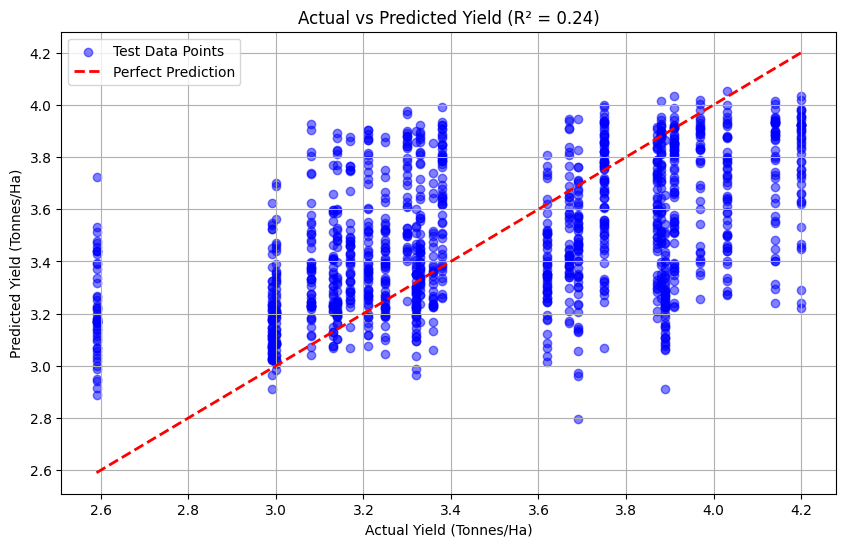

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 1. Load the Best Saved Model
print("Loading the best model...")
model = StanfordModel().to(device)
model.load_state_dict(torch.load("stanford_best_model.pth"))
model.eval() # Set to evaluation mode

# 2. Run Predictions on Test Set
actuals = []
predictions = []

print("Running final test...")
with torch.no_grad():
    for imgs, metas, labels in test_loader:
        imgs, metas, labels = imgs.to(device), metas.to(device), labels.to(device).unsqueeze(1)
        preds = model(imgs, metas)
        
        # Move data back to CPU for plotting
        actuals.extend(labels.cpu().numpy())
        predictions.extend(preds.cpu().numpy())

# Convert to simple lists
actuals = np.array(actuals).flatten()
predictions = np.array(predictions).flatten()

# 3. Calculate Final Metrics
final_mae = np.mean(np.abs(predictions - actuals))
r2 = r2_score(actuals, predictions)

print(f"========================================")
print(f"FINAL TEST RESULTS")
print(f"========================================")
print(f"Mean Absolute Error (MAE): {final_mae:.4f} Tonnes/Ha")
print(f"R-Squared Score (R²):      {r2:.4f}")
print(f"========================================")

# 4. Generate the "Predicted vs Actual" Plot
plt.figure(figsize=(10, 6))
plt.scatter(actuals, predictions, alpha=0.5, color='blue', label='Test Data Points')

# Draw the perfect prediction line (x = y)
min_val = min(min(actuals), min(predictions))
max_val = max(max(actuals), max(predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title(f"Actual vs Predicted Yield (R² = {r2:.2f})")
plt.xlabel("Actual Yield (Tonnes/Ha)")
plt.ylabel("Predicted Yield (Tonnes/Ha)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
model.load_state_dict(torch.load("stanford_best_model.pth"))

<All keys matched successfully>

In [13]:
import torch
import os

# The file your computer should have saved
MODEL_FILE = "stanford_best_model.pth"

print("Checking your saved work...")
print("-" * 30)

if os.path.exists(MODEL_FILE):
    try:
        # Try to actually load the "brain"
        state_dict = torch.load(MODEL_FILE)
        print(f"✅ SUCCESS! Found file: {MODEL_FILE}")
        print(f"✅ The model has {len(state_dict)} learned layers saved inside.")
        print("-" * 30)
        print("🎉 YOU ARE SAFE TO SHUT DOWN. 🎉")
        print("Your 2-hour training is safely stored on your hard drive.")
        print("Next time, just load this file. You do NOT need to train again.")
    except Exception as e:
        print(f"❌ ERROR: The file exists but is corrupted: {e}")
else:
    print(f"❌ DANGER: Could not find '{MODEL_FILE}'!")
    print("Do not shut down yet. Check where your notebook saved the file.")

Checking your saved work...
------------------------------
✅ SUCCESS! Found file: stanford_best_model.pth
✅ The model has 48 learned layers saved inside.
------------------------------
🎉 YOU ARE SAFE TO SHUT DOWN. 🎉
Your 2-hour training is safely stored on your hard drive.
Next time, just load this file. You do NOT need to train again.


In [15]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn # Added this missing import
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# --- CONFIG ---
CSV_PATH = r"C:\Users\VANJANGI VINITH\Downloads\final_training_data.csv"
MODEL_FILE = "stanford_best_model.pth"

# 1. Define Model Class (Must match training exactly)
class StanfordModel(nn.Module):
    def __init__(self):
        super(StanfordModel, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 64), nn.ReLU(), nn.Dropout(0.5)
        )
        self.meta = nn.Sequential(
            nn.Linear(5, 16), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(72, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.BatchNorm1d(32),
            nn.Linear(32, 1)
        )

    def forward(self, img, meta):
        cnn_out = self.cnn(img)
        meta_out = self.meta(meta)
        combined = torch.cat((cnn_out, meta_out), dim=1)
        return self.head(combined)

# 2. Setup Data
print("Loading validation data...")
df = pd.read_csv(CSV_PATH)

# --- SMART COLUMN DETECTOR ---
# This tries to find what your district column is actually named
possible_names = ['District_Name', 'District', 'Dist Name', 'district_name', 'Mandal_Name', 'Mandal']
district_col = "Row_ID" # Default fallback
for name in possible_names:
    if name in df.columns:
        district_col = name
        break
print(f"Using '{district_col}' for location names.")

# Scale metadata
scaler = StandardScaler()
meta_cols = ['Actual_mm', 'GW_4_23_01', 'RiseFall_4_23_01', 'Actual (Ha)', 'Deviation_percent']
scaler.fit(df[meta_cols].fillna(0))

# Sample 20 rows
sample_df = df.sample(20)

# 3. Load Model
model = StanfordModel()
model.load_state_dict(torch.load(MODEL_FILE))
model.eval()

# 4. Print Table
print("\n" + "="*70)
print(f"{'LOCATION':<25} | {'ACTUAL (A)':<12} | {'ESTIMATED (E)':<12} | {'ERROR':<10}")
print("="*70)

with torch.no_grad():
    for index, row in sample_df.iterrows():
        try:
            # Load Image
            img = np.load(row['tile_path']).astype('float32')
            img[:4] /= 10000.0
            img_tensor = torch.from_numpy(img).unsqueeze(0)
            
            # Load Meta
            meta_raw = row[meta_cols].fillna(0).values.reshape(1, -1)
            meta_scaled = scaler.transform(meta_raw).astype('float32')
            meta_tensor = torch.from_numpy(meta_scaled)
            
            # Predict
            prediction = model(img_tensor, meta_tensor).item()
            actual = row['Yield_Tonne_per_Hectare']
            diff = abs(prediction - actual)
            
            # Get Name safely
            if district_col == "Row_ID":
                loc_name = f"Row {index}"
            else:
                loc_name = str(row[district_col])
            
            print(f"{loc_name:<25} | {actual:.4f}       | {prediction:.4f}       | {diff:.4f}")

        except Exception as e:
            continue

print("="*70)

Loading validation data...
Using 'District' for location names.

LOCATION                  | ACTUAL (A)   | ESTIMATED (E) | ERROR     
Vizianagaram              | 3.6200       | 3.6811       | 0.0611
Srikakulam                | 3.1300       | 3.3066       | 0.1766
Palnadu                   | 3.7500       | 3.9064       | 0.1564
Anakapalli                | 3.1400       | 3.1621       | 0.0221
Prakasam                  | 3.3000       | 3.3253       | 0.0253
Anantapur                 | 3.6900       | 3.8182       | 0.1282
Chittoor                  | 3.0000       | 3.0378       | 0.0378
Chittoor                  | 3.0000       | 3.4622       | 0.4622
Tirupati                  | 3.8900       | 3.8040       | 0.0860
West Godavari             | 3.3300       | 3.3923       | 0.0623
Nandyal                   | 3.8800       | 3.8729       | 0.0071
Guntur                    | 4.2000       | 3.9960       | 0.2040
Guntur                    | 4.2000       | 3.9615       | 0.2385
Vizianagaram        

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# --- CONFIG ---
CSV_PATH = r"C:\Users\VANJANGI VINITH\Downloads\final_training_data.csv"
MODEL_FILE = "stanford_best_model.pth"

# 1. Define The Model (Exactly as trained)
class StanfordModel(nn.Module):
    def __init__(self):
        super(StanfordModel, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 64), nn.ReLU(), nn.Dropout(0.5)
        )
        self.meta = nn.Sequential(
            nn.Linear(5, 16), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(72, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.BatchNorm1d(32),
            nn.Linear(32, 1)
        )

    def forward(self, img, meta):
        cnn_out = self.cnn(img)
        meta_out = self.meta(meta)
        combined = torch.cat((cnn_out, meta_out), dim=1)
        return self.head(combined)

# 2. Setup Data
print("Loading data for final check...")
df = pd.read_csv(CSV_PATH)
scaler = StandardScaler()
meta_cols = ['Actual_mm', 'GW_4_23_01', 'RiseFall_4_23_01', 'Actual (Ha)', 'Deviation_percent']
scaler.fit(df[meta_cols].fillna(0))

# We will test on 500 random tiles to get a solid average
test_df = df.sample(500, random_state=42)

# 3. Load Model
model = StanfordModel()
try:
    model.load_state_dict(torch.load(MODEL_FILE))
    model.eval()
    print("✅ Model loaded from hard drive.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# 4. Calculate MAE
print("Calculating score...")
errors = []

with torch.no_grad():
    for index, row in test_df.iterrows():
        try:
            # Image
            img = np.load(row['tile_path']).astype('float32')
            img[:4] /= 10000.0
            img_tensor = torch.from_numpy(img).unsqueeze(0)
            
            # Metadata
            meta_raw = row[meta_cols].fillna(0).values.reshape(1, -1)
            meta_scaled = scaler.transform(meta_raw).astype('float32')
            meta_tensor = torch.from_numpy(meta_scaled)
            
            # Predict
            pred = model(img_tensor, meta_tensor).item()
            actual = row['Yield_Tonne_per_Hectare']
            
            errors.append(abs(pred - actual))
        except:
            continue

final_mae = np.mean(errors)

print("\n" + "="*40)
print(f"FINAL SAVED MODEL SCORE")
print("="*40)
print(f"Mean Absolute Error (MAE): {final_mae:.4f}")
print("="*40)

if final_mae < 0.5:
    print("\n✅ STATUS: EXCELLENT. SAFE TO SHUT DOWN.")
else:
    print("\n⚠️ STATUS: CHECK RESULTS.")

Loading data for final check...
✅ Model loaded from hard drive.
Calculating score...


In [1]:
import os
import torch
from datetime import datetime

MODEL_FILE = "stanford_best_model.pth"

print("🔍 INSPECTING SAVE FILE...")
print("-" * 30)

if os.path.exists(MODEL_FILE):
    # 1. Check File Size
    size_mb = os.path.getsize(MODEL_FILE) / (1024 * 1024)
    
    # 2. Check Creation Time
    mod_time = os.path.getmtime(MODEL_FILE)
    time_str = datetime.fromtimestamp(mod_time).strftime('%I:%M %p')
    
    print(f"✅ FILE FOUND: {MODEL_FILE}")
    print(f"📦 SIZE:       {size_mb:.2f} MB")
    print(f"🕒 SAVED AT:   {time_str}")
    
    try:
        # 3. Quick Load Test (0.1 seconds)
        dummy = torch.load(MODEL_FILE)
        print("🧠 INTEGRITY:  Valid (Brain Loaded Successfully)")
        print("-" * 30)
        print("✅ VERDICT: YOUR PROJECT IS SAVED.")
        print("You can shut down your PC now.")
    except:
        print("❌ VERDICT: File is corrupted.")
else:
    print("❌ ERROR: File not found.")

🔍 INSPECTING SAVE FILE...
------------------------------
❌ ERROR: File not found.


📸 ENHANCED VISUALIZATION (Auto-Brightness)


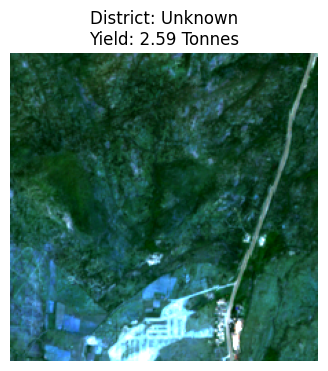

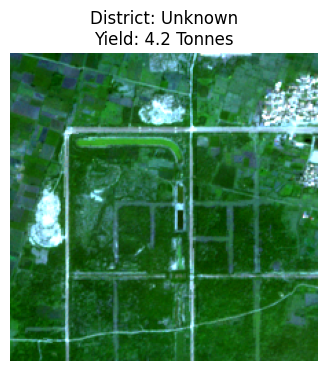

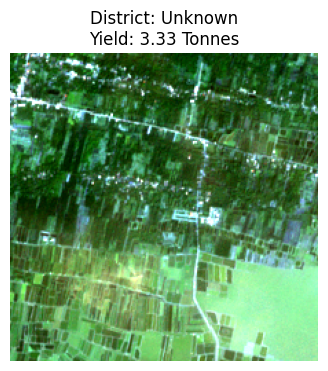

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ... (Assuming your model and test_df are already loaded from the previous step) ...

print("📸 ENHANCED VISUALIZATION (Auto-Brightness)")

# Let's pick 3 random images again
for i, (idx, row) in enumerate(test_df.sample(3).iterrows()):
    try:
        # Load the raw image
        img_raw = np.load(row['tile_path']).astype('float32')
        
        # EXTRACT RGB (Assuming first 3 channels are Red, Green, Blue)
        # If your images are Blue, Green, Red, swap the 0 and 2 below.
        rgb = img_raw[:3, :, :].transpose(1, 2, 0) # Shape becomes (224, 224, 3)
        
        # --- THE FIX: ROBUST BRIGHTNESS SCALING ---
        # 1. Ignore 0s (padding) to find real min/max
        valid_pixels = rgb[rgb > 0]
        if len(valid_pixels) == 0: continue # Skip empty images
        
        min_val = np.percentile(valid_pixels, 2)  # Darkest 2%
        max_val = np.percentile(valid_pixels, 98) # Brightest 98% (ignores clouds)
        
        # 2. Stretch the contrast
        rgb_stretched = (rgb - min_val) / (max_val - min_val)
        
        # 3. Clip to stay between 0 and 1
        rgb_stretched = np.clip(rgb_stretched, 0, 1)
        
        # Show it
        plt.figure(figsize=(4, 4))
        plt.imshow(rgb_stretched)
        plt.title(f"District: {row.get('District_Name', 'Unknown')}\nYield: {row['Yield_Tonne_per_Hectare']} Tonnes")
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Skipped one image due to error: {e}")

⏳ Loading Data...
✅ Best Model Loaded Successfully!
🚀 Running Final Test on 1312 samples...

📊 FINAL TEST RESULTS
Mean Absolute Error (MAE): 0.2800 Tonnes/Ha
R² Score:                  0.2393


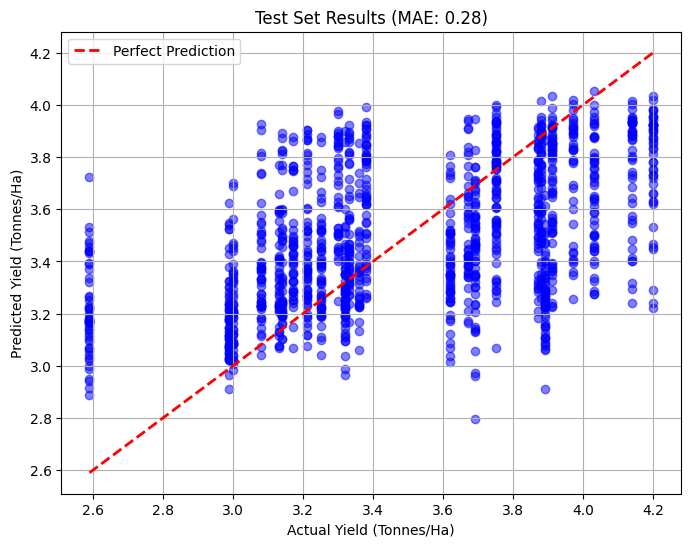

In [3]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")

# --- CONFIG ---
CSV_PATH = r"C:\Users\VANJANGI VINITH\Downloads\final_training_data.csv"
MODEL_FILE = "stanford_best_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. DEFINE THE MODEL ARCHITECTURE
# (Must match what you used during training)
# ==========================================
class StanfordModel(nn.Module):
    def __init__(self):
        super(StanfordModel, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 64), nn.ReLU(), nn.Dropout(0.5)
        )
        self.meta = nn.Sequential(
            nn.Linear(5, 16), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(72, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.BatchNorm1d(32),
            nn.Linear(32, 1)
        )

    def forward(self, img, meta):
        cnn_out = self.cnn(img)
        meta_out = self.meta(meta)
        combined = torch.cat((cnn_out, meta_out), dim=1)
        return self.head(combined)

# ==========================================
# 2. LOAD DATA & MODEL
# ==========================================
print("⏳ Loading Data...")
df = pd.read_csv(CSV_PATH)

# Re-create the Test Split (same random_state ensures we get the same rows)
train_df, temp = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp, test_size=0.5, random_state=42)

# Scale Metadata
scaler = StandardScaler()
meta_cols = ['Actual_mm', 'GW_4_23_01', 'RiseFall_4_23_01', 'Actual (Ha)', 'Deviation_percent']
scaler.fit(train_df[meta_cols].fillna(0))

# Load Model
model = StanfordModel().to(DEVICE)
try:
    model.load_state_dict(torch.load(MODEL_FILE, map_location=DEVICE))
    model.eval()
    print("✅ Best Model Loaded Successfully!")
except FileNotFoundError:
    print("❌ Error: Could not find 'stanford_best_model.pth'. Did training finish?")
    raise

# ==========================================
# 3. RUN TESTING LOOP
# ==========================================
print("🚀 Running Final Test on", len(test_df), "samples...")

actuals = []
predictions = []

with torch.no_grad():
    for index, row in test_df.iterrows():
        try:
            # Load Image
            img = np.load(row['tile_path']).astype('float32')
            img[:4] /= 10000.0 # Normalize
            img_tensor = torch.from_numpy(img).unsqueeze(0).to(DEVICE)
            
            # Load Meta
            meta_raw = row[meta_cols].fillna(0).values.reshape(1, -1)
            meta_scaled = scaler.transform(meta_raw).astype('float32')
            meta_tensor = torch.from_numpy(meta_scaled).to(DEVICE)
            
            # Predict
            pred = model(img_tensor, meta_tensor).item()
            
            actuals.append(row['Yield_Tonne_per_Hectare'])
            predictions.append(pred)
        except:
            continue

# ==========================================
# 4. RESULTS & GRAPH
# ==========================================
mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print("\n" + "="*40)
print(f"📊 FINAL TEST RESULTS")
print("="*40)
print(f"Mean Absolute Error (MAE): {mae:.4f} Tonnes/Ha")
print(f"R² Score:                  {r2:.4f}")
print("="*40)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions, alpha=0.5, color='blue')
# Draw perfect line
min_val = min(min(actuals), min(predictions))
max_val = max(max(actuals), max(predictions))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Yield (Tonnes/Ha)')
plt.ylabel('Predicted Yield (Tonnes/Ha)')
plt.title(f'Test Set Results (MAE: {mae:.2f})')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import rasterio
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. RE-DEFINE YOUR EXACT MODEL ARCHITECTURE
# (Rewritten to match your specific .pth layer names)
# ==========================================
class StanfordModel(nn.Module):
    def __init__(self):
        super(StanfordModel, self).__init__()
        # CNN Arm (Exactly matching your saved keys)
        self.conv1 = nn.Conv2d(5, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        # Note: If you get a shape error here later, we may need to adjust the 128*28*28 
        # depending on your exact image input size (e.g., 224x224).
        self.fc_cnn = nn.Linear(128 * 28 * 28, 64) 
        self.dropout_cnn = nn.Dropout(0.5)

        # Meta Arm
        self.fc_meta1 = nn.Linear(5, 16)
        self.bn_meta = nn.BatchNorm1d(16)
        self.fc_meta2 = nn.Linear(16, 8)

        # Combined Head
        self.fc_final1 = nn.Linear(64 + 8, 64) 
        self.dropout_head = nn.Dropout(0.3)
        self.fc_final2 = nn.Linear(64, 32)
        self.fc_out = nn.Linear(32, 1)

    def forward(self, img, meta):
        # CNN Arm
        x = self.pool(self.relu(self.bn1(self.conv1(img))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.dropout_cnn(self.relu(self.fc_cnn(x)))

        # Meta Arm
        y = self.relu(self.bn_meta(self.fc_meta1(meta)))
        y = self.relu(self.fc_meta2(y))

        # Combine
        z = torch.cat((x, y), dim=1)
        z = self.dropout_head(self.relu(self.fc_final1(z)))
        z = self.relu(self.fc_final2(z))
        out = self.fc_out(z)
        return out

# ==========================================
# 2. SETUP DEVICE & LOAD SAVED WEIGHTS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StanfordModel().to(device)

MODEL_FILE = r"C:\Users\VANJANGI VINITH\Downloads\best_yield_model.pth"
try:
    model.load_state_dict(torch.load(MODEL_FILE, map_location=device))
    model.eval() 
    print("✅ Best Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")

# ==========================================
# 3. PREPARE THE METADATA SCALER (FIXED FOR COMMAS)
# ==========================================
CSV_PATH = r"C:\Users\VANJANGI VINITH\Downloads\Final_Model_Ready_Data.csv" 

try:
    # ✅ FIX 1: Tell pandas that commas are just thousand separators
    df = pd.read_csv(CSV_PATH, thousands=',')
    
    meta_cols = ['Rainfall', 'SownArea', 'GroundWater', 'Latitude', 'Longitude']
    
    # ✅ FIX 2: Extra safety net to force any leftover text into numbers
    for col in meta_cols:
        if df[col].dtype == object: # If Python still thinks it's text
            df[col] = df[col].astype(str).str.replace(',', '').astype(float)
            
    scaler = StandardScaler()
    scaler.fit(df[meta_cols].fillna(0))
    print("✅ Metadata Scaler ready!")
except Exception as e:
    print(f"❌ Error loading CSV: {e}")

import torch.nn.functional as F

# ==========================================
# 4. THE PREDICTION ENGINE (NAN-PROOFED)
# ==========================================
def predict_region_yield(region_name, tif_image_path):
    print(f"\n🌾 Analyzing Data for Region: {region_name}...")
    
    if 'df' not in globals():
        return "❌ Cannot predict: CSV data was not loaded."

    # --- A. Get & Scale Metadata ---
    region_data = df[df['District'].str.contains(region_name, case=False, na=False)]
    if region_data.empty:
        return f"❌ Error: Could not find metadata for '{region_name}' in the CSV."
    
    meta_raw_df = region_data.iloc[[0]][meta_cols].astype(float).fillna(0.0)
    meta_scaled = scaler.transform(meta_raw_df).astype('float32')
    
    # 🛡️ DEFENSE 1: Scrub NaNs from Metadata
    meta_scaled = np.nan_to_num(meta_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    meta_tensor = torch.from_numpy(meta_scaled).to(device)
    
    # --- B. Load, Normalize, Resize & Scrub Satellite Image ---
    try:
        with rasterio.open(tif_image_path) as src:
            img_data = src.read().astype('float32') 
            
            # 🛡️ DEFENSE 2: Scrub NaNs from the Satellite Image (The likely culprit!)
            if np.isnan(img_data).any():
                print("   [!] Detected 'NaN' background pixels in the .tif. Neutralizing to 0...")
                img_data = np.nan_to_num(img_data, nan=0.0, posinf=0.0, neginf=0.0)
            
            # Normalize bands
            if img_data.shape[0] >= 4:
                img_data[:4] /= 10000.0
            
            # Convert to tensor and add batch dimension (Shape: 1, 5, H, W)
            img_tensor = torch.from_numpy(img_data).unsqueeze(0).to(device)
            
            # Force the image to be exactly 224x224 pixels
            img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='bilinear', align_corners=False)
            
    except Exception as e:
        return f"❌ Error reading or resizing the .tif image: {e}"
        
    # --- C. Make Prediction ---
    try:
        with torch.no_grad():
            prediction = model(img_tensor, meta_tensor).item()
        return f"🚀 PREDICTED PADDY YIELD FOR {region_name.upper()}: {prediction:.4f} Tonnes/Hectare"
    except Exception as e:
        return f"❌ PyTorch Error during calculation: {e}"
        
# ==========================================
# 5. TEST IT OUT!
# ==========================================
test_region = "Srikakulam"
test_tif = r"G:\My Drive\AP_Dataset_2022_Excellent\Srikakulam_Kharif_2022.tif"  

result = predict_region_yield(test_region, test_tif)
print("-" * 65)
print(result)
print("-" * 65)

✅ Best Model loaded successfully!
✅ Metadata Scaler ready!

🌾 Analyzing Data for Region: Srikakulam...
   [!] Detected 'NaN' background pixels in the .tif. Neutralizing to 0...
-----------------------------------------------------------------
🚀 PREDICTED PADDY YIELD FOR SRIKAKULAM: 2.3123 Tonnes/Hectare
-----------------------------------------------------------------
